# TSP Experiment: Deterministic vs. Randomized Nearest Neighbor

This notebook is the full experiment pipeline comparing deterministic
Nearest Neighbor (NN) against Randomized Nearest Neighbor (RNN) variants for
the Travelling Salesman Problem. It is organised in parts, added over time:

- **Part 1 (this section): Dataset generation.** Creates and saves every
  problem instance to `data/`.
- *Later parts (not yet added): running the algorithms against this
  dataset, and analysing the results.*

Every generator function in `datasets.py` takes its parameters as explicit
arguments — nothing is hardcoded inside the functions themselves. This
notebook is where every parameter is actually chosen and explained; the
functions just carry out whatever configuration they're given.

---

## Part 1: Dataset Generation


In [1]:
import datasets

### What the dataset contains

Three categories of TSP problem instance, covering both the classical
theoretical formulation and a more realistic, practical one:

| Category | What it represents | Count |
|---|---|---|
| **Euclidean** | Complete graph, straight-line (symmetric) distances — the standard textbook TSP formulation | 500 generated |
| **Distance-matrix** | Incomplete, directional graph — not every city pair has a direct route, and A→B need not cost the same as B→A (e.g. a real road network) | 500 generated |
| **TSPLIB** | Real-world benchmark problems with externally published (often provably optimal) tour lengths, used as ground truth | 82 bundled |

**Why both Euclidean and distance-matrix?** The standard TSP formulation
assumes a complete graph — a direct route between every pair of cities.
That's a reasonable simplification, but it hides a real algorithmic risk:
Nearest Neighbor's greedy choices can strand cities in a way that's only
exposed when direct routes genuinely don't exist between every pair. The
distance-matrix category tests exactly that scenario.


### Instance-size buckets

Rather than testing at a handful of arbitrary fixed sizes, or drawing sizes
from a single distribution centered on one "typical" value (which would
under-sample small and large instances), instance sizes are drawn from a set
of fixed ranges ("buckets"). Within each bucket, the size `n` is normally
distributed around the bucket's median, with a standard deviation of
`(bucket_width) / SIGMA_DIVISOR` — `SIGMA_DIVISOR = 6` means roughly 99.7%
of draws land inside the bucket without needing to clip.

This guarantees every scale gets a full, deliberate allocation of the
dataset, while values *within* each bucket still cluster naturally around a
typical size instead of landing on the exact same repeated number every
time.

`SIZE_BUCKETS` below is the actual configuration used — defined here,
explicitly, rather than pulled from a hidden default inside `datasets.py`.


In [2]:
# 8 buckets spanning 3..5000 cities. Each tuple is (low, high) in
# number-of-cities. Passed explicitly into every generator call below.
SIZE_BUCKETS = [
    (3, 10),
    (10, 20),
    (20, 50),
    (50, 100),
    (100, 200),
    (200, 500),
    (500, 1000),
    (1000, 5000),
]

# Standard deviation for the normal-within-bucket size sampling, as a
# fraction of each bucket's width (width / SIGMA_DIVISOR). 6 means ~99.7%
# of draws land inside the bucket.
SIGMA_DIVISOR = 6

# Safety ceiling: a generation call refuses to run if `total` exceeds this,
# so a typo'd instance count can't silently produce an enormous dataset.
MAX_TOTAL_INSTANCES = 1200

for i, (low, high) in enumerate(SIZE_BUCKETS):
    median = (low + high) / 2
    sigma = (high - low) / SIGMA_DIVISOR
    print(f"bucket {i}: n in [{low:>5}, {high:>5}]  (median={median:>7.1f}, sigma={sigma:>6.1f})")


bucket 0: n in [    3,    10]  (median=    6.5, sigma=   1.2)
bucket 1: n in [   10,    20]  (median=   15.0, sigma=   1.7)
bucket 2: n in [   20,    50]  (median=   35.0, sigma=   5.0)
bucket 3: n in [   50,   100]  (median=   75.0, sigma=   8.3)
bucket 4: n in [  100,   200]  (median=  150.0, sigma=  16.7)
bucket 5: n in [  200,   500]  (median=  350.0, sigma=  50.0)
bucket 6: n in [  500,  1000]  (median=  750.0, sigma=  83.3)
bucket 7: n in [ 1000,  5000]  (median= 3000.0, sigma= 666.7)


### Category 1: Euclidean instances

Complete graphs with symmetric, straight-line (Euclidean) distances — the
standard TSP formulation. Every instance is placed inside a
`WIDTH x HEIGHT` rectangle, using one of two spatial structures:

- **`random`**: cities placed uniformly at random across the rectangle.
- **`clustered`**: cities drawn from `NUM_CLUSTERS` Gaussian "blobs" (each
  blob's spread controlled by `CLUSTER_STD`), instead of uniformly — this
  tests robustness to non-uniform, real-world-like spatial structure (e.g.
  cities bunched around a few population centers rather than spread evenly).

`STRUCTURE_RATIO` controls the mix: the fraction of instances generated as
`clustered` rather than `random`. `STRUCTURE_RATIO = 0.5` means roughly an
even split; `0.0` would make every instance uniform-random, `1.0` would make
every instance clustered.

**Storage format:** one JSON file per instance in `data/euclidean/`,
containing the instance's metadata (name, structure, bucket, size, seed) and
its city coordinates. Coordinates are enough to reconstruct the full
distance matrix on demand, so nothing else needs to be stored.


In [3]:
# --- Euclidean dataset configuration ---
EUCLIDEAN_TOTAL = 500
EUCLIDEAN_SEED = 1000
EUCLIDEAN_OUT_DIR = "data/euclidean"

STRUCTURE_RATIO = 0.5   # fraction of instances that are "clustered" vs "random"
NUM_CLUSTERS = 5        # clustered instances: number of Gaussian blobs
CLUSTER_STD = 50        # clustered instances: spread (std dev) of each blob

WIDTH = 1000            # map width, in the same units as tour length
HEIGHT = 1000           # map height

euclidean_manifest = datasets.generate_euclidean_dataset(
    total=EUCLIDEAN_TOTAL,
    buckets=SIZE_BUCKETS,
    seed=EUCLIDEAN_SEED,
    out_dir=EUCLIDEAN_OUT_DIR,
    max_total=MAX_TOTAL_INSTANCES,
    structure_ratio=STRUCTURE_RATIO,
    num_clusters=NUM_CLUSTERS,
    cluster_std=CLUSTER_STD,
    width=WIDTH,
    height=HEIGHT,
    sigma_divisor=SIGMA_DIVISOR,
)

structures = {}
for row in euclidean_manifest:
    structures[row["structure"]] = structures.get(row["structure"], 0) + 1

sizes = [row["n"] for row in euclidean_manifest]
print(f"generated {len(euclidean_manifest)} euclidean instances")
print(f"structure breakdown: {structures}")
print(f"size range: {min(sizes)} .. {max(sizes)}")


generated 500 euclidean instances
structure breakdown: {'clustered': 237, 'random': 263}
size range: 4 .. 5000


### Category 2: Distance-matrix instances

Incomplete, **directional** reachability graphs — a more realistic model of
routing where not every pair of locations has a direct connection, and a
route that exists in one direction need not exist (or cost the same) in the
other (e.g. a one-way street, or a downhill-only mountain trail).

Cities are placed uniformly at random in a `WIDTH x HEIGHT` rectangle, then
sparsified by one of **three different methods**, mixed by `METHOD_WEIGHTS`
so the dataset contains all three rather than just one:

- **`knn`** (k-nearest-neighbour): each city keeps outgoing edges only to
  its `k = max(K_MIN, round(K_FRACTION * n))` nearest neighbours — every
  other pair is unreachable. The most "realistic" of the three: distance
  directly determines which routes exist.
- **`barrier`**: cities are split into two groups by a line through the
  middle of the map (like a river or mountain range). Within each side,
  the same k-nearest-neighbour rule applies; *crossing* the barrier is only
  possible through `NUM_BRIDGES` specific city pairs (bidirectional, at
  their real distance) — every other cross-side pair is unreachable. Tests
  whether a geographic bottleneck (not just general sparsity) changes
  algorithm behaviour.
- **`random_drop`**: each directed pair `(i, j)` is independently kept with
  probability `KEEP_PROBABILITY`, **unrelated to distance**. The least
  physically realistic of the three, but a useful control: does *structured*
  sparsity (knn, barrier) actually matter, or does equally-sparse
  *unstructured* randomness produce similar results?

**Feasibility guarantee (all three methods):** a random Hamiltonian cycle's
directed edges are always force-kept on top of whichever sparsification
applies, guaranteeing at least one valid tour exists by construction —
directly verifying Hamiltonian-cycle existence in an arbitrary sparse graph
is computationally infeasible at n in the thousands, so the backbone cycle
sidesteps that problem entirely.

**Choosing `K_FRACTION` / `KEEP_PROBABILITY`:** an earlier attempt used
`K_FRACTION = 0.10` (10% of n). At n=5000 that still means 500 direct
connections per city — not meaningfully sparse, and it produced a 1.7GB
dataset dominated almost entirely by the largest size bucket. `0.01` (1%) is
used for both instead, which is both more realistic (a real road network has
roughly a *constant* number of direct connections per intersection, not a
number that scales with the size of the whole country) and keeps all three
methods at a comparable, bounded edge density.

**Storage format:** each instance is a CSV edge list (`from,to,distance`,
one row per *existing* edge only) plus a small JSON metadata sidecar, in
`data/distance_matrix/`. This folder is excluded from version control
(see `.gitignore`) because it is regenerable and too large to commit —
rerunning this notebook reproduces it exactly, since every draw is seeded.


In [4]:
# --- Distance-matrix dataset configuration ---
SPARSE_TOTAL = 500
SPARSE_SEED = 2000
SPARSE_OUT_DIR = "data/distance_matrix"

# Relative weights for how often each instance uses each sparsification
# method -- need not sum to 1, they're normalised automatically. Equal
# weights here means roughly an even three-way split.
METHOD_WEIGHTS = {"knn": 1, "barrier": 1, "random_drop": 1}

K_FRACTION = 0.01         # knn / barrier: each city keeps K_FRACTION * n nearest neighbours
K_MIN = 2                 # ...but never fewer than K_MIN, even at tiny n
NUM_BRIDGES = 2           # barrier: number of crossing points between the two sides
KEEP_PROBABILITY = 0.01   # random_drop: probability each directed edge is kept at all

distance_matrix_manifest = datasets.generate_distance_matrix_dataset(
    total=SPARSE_TOTAL,
    buckets=SIZE_BUCKETS,
    seed=SPARSE_SEED,
    out_dir=SPARSE_OUT_DIR,
    max_total=MAX_TOTAL_INSTANCES,
    method_weights=METHOD_WEIGHTS,
    k_fraction=K_FRACTION,
    k_min=K_MIN,
    num_bridges=NUM_BRIDGES,
    keep_probability=KEEP_PROBABILITY,
    width=WIDTH,
    height=HEIGHT,
    sigma_divisor=SIGMA_DIVISOR,
)

sizes = [row["n"] for row in distance_matrix_manifest]
edges = [row["edge_count"] for row in distance_matrix_manifest]
methods = {}
for row in distance_matrix_manifest:
    methods[row["structure"]] = methods.get(row["structure"], 0) + 1

print(f"generated {len(distance_matrix_manifest)} distance-matrix instances")
print(f"method breakdown: {methods}")
print(f"size range: {min(sizes)} .. {max(sizes)}")
print(f"total edges stored: {sum(edges):,}")
print(f"edges per instance: min={min(edges):,}, max={max(edges):,}, mean={sum(edges)/len(edges):,.0f}")


generated 500 distance-matrix instances
method breakdown: {'barrier': 174, 'random_drop': 157, 'knn': 169}
size range: 4 .. 4507
total edges stored: 6,573,012
edges per instance: min=4, max=207,278, mean=13,146


### Category 3: TSPLIB benchmarks

Real, externally published TSP instances from
[TSPLIB](http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/), bundled in
`data/tsplib/`. Unlike the two categories above, these are not generated —
they are real problems (city coordinates from real atlases, circuit-board
drilling points, etc.) with known best/optimal tour lengths, published in
`data/tsplib/solutions.txt`. They matter because they let later analysis
check algorithm performance against **true, externally verified** ground
truth, rather than only "the best tour length observed among the algorithms
being compared" (which is a weaker, self-referential reference).


In [5]:
TSPLIB_DIR = datasets.TSPLIB_DIR  # "data/tsplib"

tsplib_names = datasets.list_tsplib_instances(directory=TSPLIB_DIR)
solutions = datasets.load_tsplib_solutions(directory=TSPLIB_DIR)

tsplib_manifest = []
for name in tsplib_names:
    dim = datasets.get_tsplib_dimension(f"{TSPLIB_DIR}/{name}.tsp")
    tsplib_manifest.append({
        "name": name,
        "category": "tsplib",
        "structure": "tsplib",
        "bucket_index": "",
        "bucket_low": "",
        "bucket_high": "",
        "n": dim,
        "seed": "",
        "edge_count": "",
        "file": f"{TSPLIB_DIR}/{name}.tsp",
    })

dims = [row["n"] for row in tsplib_manifest]
known = sum(1 for row in tsplib_manifest if row["name"] in solutions)
print(f"found {len(tsplib_manifest)} TSPLIB instances")
print(f"size range: {min(dims)} .. {max(dims)}")
print(f"instances with a published optimal/best-known length: {known}")


found 82 TSPLIB instances
size range: 51 .. 85900
instances with a published optimal/best-known length: 82


### Dataset overview

A quick visual sanity check: instance-size coverage across all buckets for
both generated categories, and how the distance-matrix edge count grows with
n.


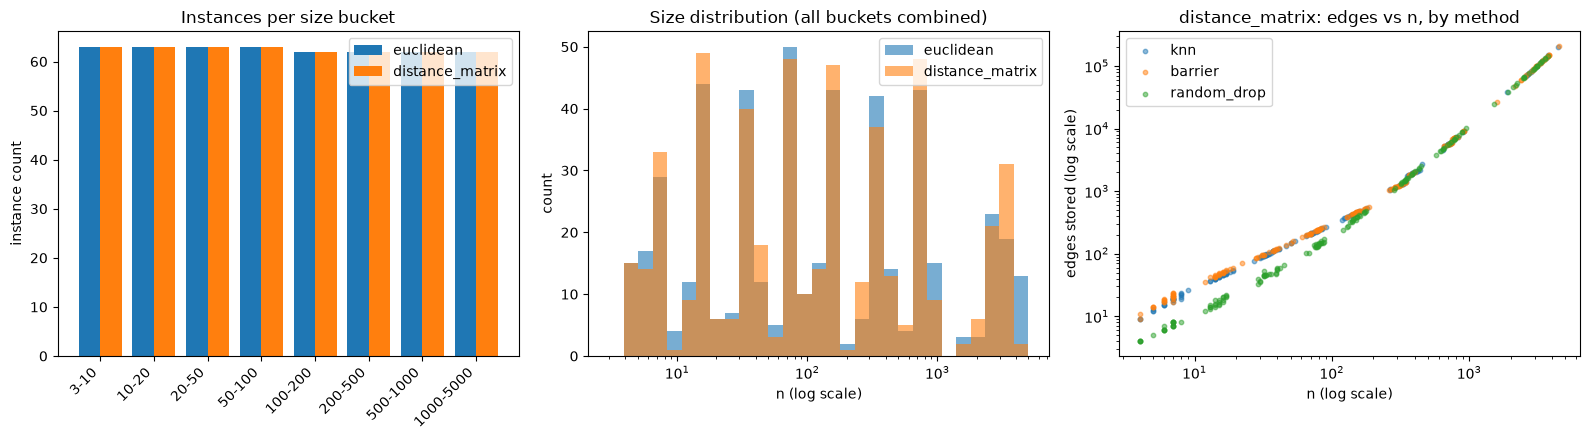

In [6]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Panel 1: bucket coverage (instance count per bucket, per category)
bucket_labels = [f"{lo}-{hi}" for lo, hi in SIZE_BUCKETS]
euclid_counts = [sum(1 for r in euclidean_manifest if r["bucket_index"] == i) for i in range(len(SIZE_BUCKETS))]
sparse_counts = [sum(1 for r in distance_matrix_manifest if r["bucket_index"] == i) for i in range(len(SIZE_BUCKETS))]

x = np.arange(len(SIZE_BUCKETS))
axes[0].bar(x - 0.2, euclid_counts, width=0.4, label="euclidean")
axes[0].bar(x + 0.2, sparse_counts, width=0.4, label="distance_matrix")
axes[0].set_xticks(x)
axes[0].set_xticklabels(bucket_labels, rotation=45, ha="right")
axes[0].set_ylabel("instance count")
axes[0].set_title("Instances per size bucket")
axes[0].legend()

# Panel 2: size distribution within buckets (log scale, both categories).
# Bins must be log-spaced too, or a log x-axis just piles everything into
# the first (linear-width) bin.
log_bins = np.logspace(np.log10(SIZE_BUCKETS[0][0]), np.log10(SIZE_BUCKETS[-1][1]), 30)
axes[1].hist([r["n"] for r in euclidean_manifest], bins=log_bins, alpha=0.6, label="euclidean")
axes[1].hist([r["n"] for r in distance_matrix_manifest], bins=log_bins, alpha=0.6, label="distance_matrix")
axes[1].set_xscale("log")
axes[1].set_xlabel("n (log scale)")
axes[1].set_ylabel("count")
axes[1].set_title("Size distribution (all buckets combined)")
axes[1].legend()

# Panel 3: edge count vs n for the distance-matrix category, by method
axes[2].set_xscale("log")
axes[2].set_yscale("log")
for method in METHOD_WEIGHTS:
    rows = [r for r in distance_matrix_manifest if r["structure"] == method]
    axes[2].scatter([r["n"] for r in rows], [r["edge_count"] for r in rows], s=10, alpha=0.5, label=method)
axes[2].set_xlabel("n (log scale)")
axes[2].set_ylabel("edges stored (log scale)")
axes[2].set_title("distance_matrix: edges vs n, by method")
axes[2].legend()

plt.tight_layout()
plt.savefig("data/dataset_overview.png", dpi=110)
plt.show()


### Part 1 summary

| | Count |
|---|---|
| Euclidean instances | `EUCLIDEAN_TOTAL` |
| Distance-matrix instances | `SPARSE_TOTAL` |
| TSPLIB benchmark instances | (all bundled instances found) |

All generated instances (Euclidean and distance-matrix) are fully
reproducible from their stored seed — rerunning this section with the same
configuration values regenerates byte-identical output.

**Part 1 stops here.** Running NN/RNN algorithms against this dataset, and
analysing the results, will be added as later parts of this notebook.


In [7]:
total = len(euclidean_manifest) + len(distance_matrix_manifest) + len(tsplib_manifest)
print(f"euclidean:       {len(euclidean_manifest)}")
print(f"distance_matrix: {len(distance_matrix_manifest)}")
print(f"tsplib:          {len(tsplib_manifest)}")
print(f"total:           {total}")


euclidean:       500
distance_matrix: 500
tsplib:          82
total:           1082
